# Mini Project — Part 2 Extension
## Predicting Coral Reef Regimes from Human and Natural Influences

### Additional model: K-Nearest Neighbors (KNN)

This notebook implements **Part 2** of the mini-project using K-Nearest Neighbors (KNN), an additional classifier not included in the reference project's reported model comparison.

**Goal:** use the same prepared dataset, the same 80/20 train-test split, the same 25-feature representation, 5-fold cross-validation, and micro-averaged F1 metric so that the extension is directly comparable to the reference models.

Reference paper: *Predicting Coral Reef Regimes from Human and Natural Influences* (CS229, 2019).


## 1. What Part 2 must demonstrate

According to the mini-project guidelines, the additional model must:

1. Be a model not used in the reference.
2. Use the same dataset.
3. Use the same train/test split.
4. Use the same evaluation metric.
5. Be trained and evaluated fairly.
6. Be briefly justified.
7. Be compared with the reference models.
8. Clearly state whether it performs better, worse, or similarly.

### Why KNN?

The reference project reported Logistic Regression, SVM, Random Forest, and Gradient Boosted Tree models. KNN gives us a different, distance-based classification approach. It is also computationally inexpensive for this small dataset.

Because KNN depends on distances, **feature standardization is essential**. The scaler is therefore placed inside a scikit-learn Pipeline so that scaling is fitted only on each training fold during cross-validation.


In [20]:
# Install / import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the exact prepared data used by the reference project

The CS229 project repository provides separate prepared train, validation, and test files. The original project combines its train and validation portions when performing 5-fold cross-validation, giving **496 training observations**, while the held-out test set contains **124 observations**.

We reproduce that setup here by combining the repository's `Predictors_complete_train.txt` and `Predictors_complete_val.txt`, while keeping `Predictors_complete_test.txt` untouched until final evaluation.


In [21]:
# URLs for the prepared data in the original project repository
TRAIN_URL = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_train.txt"
VAL_URL   = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_val.txt"
TEST_URL  = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_test.txt"

train_part = pd.read_csv(TRAIN_URL, sep="\t", decimal=",")
val_part   = pd.read_csv(VAL_URL, sep="\t", decimal=",")
test_df    = pd.read_csv(TEST_URL, sep="\t", decimal=",")

train_df = pd.concat([train_part, val_part], ignore_index=True)

print("Original train portion:", train_part.shape)
print("Original validation portion:", val_part.shape)
print("Combined training data:", train_df.shape)
print("Held-out test data:", test_df.shape)


Original train portion: (396, 46)
Original validation portion: (100, 46)
Combined training data: (496, 46)
Held-out test data: (124, 46)


In [22]:
# Check the expected split
assert len(train_df) == 496, f"Expected 496 training observations, got {len(train_df)}"
assert len(test_df) == 124, f"Expected 124 test observations, got {len(test_df)}"

print("✓ Training set = 496 observations")
print("✓ Test set = 124 observations")
print("✓ 80/20 split reproduced")


✓ Training set = 496 observations
✓ Test set = 124 observations
✓ 80/20 split reproduced


## 3. Select the same 25 predictors

The reference project uses **20 original predictors** and adds **5 engineered interaction features**.

The original Random Forest notebook identifies the 20 original predictors as:

- Effluent
- Sedimentation
- New_Development
- Habitat_Modification
- Invasive_Algae
- Fishing_Comm_Total
- Fishing_NonComm_Boat_Total
- Fishing_NonComm_Shore_Line
- Fishing_NonComm_Shore_Net
- Fishing_NonComm_Shore_Spear
- SST_CLIM_M
- SST_STD
- CHL_CLIM_M
- CHL_ANOM_F
- PAR_CLIM_M
- PAR_STD
- WAV_CLIM_M
- WAV_ANOM_F
- Complexity
- Depth

The five engineered features are:

- `sqrt_power_x_compexity`
- `log_power_over_depth`
- `complexity_over_depth`
- `Irradiance_x_inv_algae`
- `both_anomolies`

The prepared `complete` files already contain these engineered features and the imputed values used by the reference project, so we use them directly rather than recreating the preprocessing differently.


In [23]:
ORIGINAL_FEATURES = [
    "Effluent",
    "Sedimentation",
    "New_Development",
    "Habitat_Modification",
    "Invasive_Algae",
    "Fishing_Comm_Total",
    "Fishing_NonComm_Boat_Total",
    "Fishing_NonComm_Shore_Line",
    "Fishing_NonComm_Shore_Net",
    "Fishing_NonComm_Shore_Spear",
    "SST_CLIM_M",
    "SST_STD",
    "CHL_CLIM_M",
    "CHL_ANOM_F",
    "PAR_CLIM_M",
    "PAR_STD",
    "WAV_CLIM_M",
    "WAV_ANOM_F",
    "Complexity",
    "Depth"
]

ENGINEERED_FEATURES = [
    "sqrt_power_x_compexity",
    "log_power_over_depth",
    "complexity_over_depth",
    "Irradiance_x_inv_algae",
    "both_anomolies"
]

FEATURES = ORIGINAL_FEATURES + ENGINEERED_FEATURES
TARGET = "Regime"

print("Number of original predictors:", len(ORIGINAL_FEATURES))
print("Number of engineered predictors:", len(ENGINEERED_FEATURES))
print("Total predictors:", len(FEATURES))

assert len(FEATURES) == 25


Number of original predictors: 20
Number of engineered predictors: 5
Total predictors: 25


In [24]:
# Create X/y
X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

# Confirm that every feature is numeric
print("Non-numeric training columns:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())

print("\nMissing values in X_train:", int(X_train.isna().sum().sum()))
print("Missing values in X_test:", int(X_test.isna().sum().sum()))

assert X_train.select_dtypes(exclude=np.number).shape[1] == 0
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0


Non-numeric training columns:
[]

Missing values in X_train: 0
Missing values in X_test: 0


## 4. Inspect the target distribution

The problem is a multiclass classification task. The reference paper uses **micro-averaged F1** because the reef-regime classes are imbalanced.

We will use `f1_micro` for both hyperparameter selection and final test evaluation.


In [25]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTraining class proportions:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")


Training class distribution:
Regime
1    127
2    135
3    118
5    116
Name: count, dtype: int64

Training class proportions:
Regime
1     25.6%
2    27.22%
3    23.79%
5    23.39%
Name: proportion, dtype: object


## 5. Build the KNN pipeline

KNN is sensitive to feature scale because it uses distances between observations.

We therefore use:

`StandardScaler → KNeighborsClassifier`

Putting the scaler inside the Pipeline is important: during each cross-validation fold, the scaler is fitted only on that fold's training data. This prevents information leakage from the validation fold.


In [26]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

print(knn_pipeline)


Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


## 6. Hyperparameter tuning with 5-fold cross-validation

The reference project uses 5-fold cross-validation and tunes model hyperparameters using cross-validation.

For KNN we tune:

- `n_neighbors`: number of neighbors
- `weights`: uniform vs. distance-weighted neighbors
- `metric`: Euclidean vs. Manhattan distance

We optimize **micro-averaged F1**, matching the reference metric.


In [27]:
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring="f1_micro",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest 5-fold CV Micro-F1:")
print(round(grid_search.best_score_, 4))


Best parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}

Best 5-fold CV Micro-F1:
0.6693


## 7. Inspect the cross-validation results

This table lets us show that the final KNN configuration was selected using the training data and 5-fold CV rather than by looking at the test set.


In [28]:
cv_results = pd.DataFrame(grid_search.cv_results_)

results_table = cv_results[
    [
        "param_knn__n_neighbors",
        "param_knn__weights",
        "param_knn__metric",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

results_table.head(10)


,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
21,7,distance,manhattan,1.000000,0.669293,0.045298,1
19,5,distance,manhattan,1.000000,0.669253,0.043692,2
17,3,distance,manhattan,1.000000,0.663253,0.051657,3
29,21,distance,manhattan,1.000000,0.663232,0.057374,4
27,15,distance,manhattan,1.000000,0.661253,0.044789,5
25,11,distance,manhattan,1.000000,0.661232,0.058706,6
23,9,distance,manhattan,1.000000,0.661212,0.049367,7
1,3,distance,euclidean,1.000000,0.659131,0.053930,8
31,31,distance,manhattan,1.000000,0.653152,0.059824,9
26,15,uniform,manhattan,0.692535,0.651192,0.031846,10


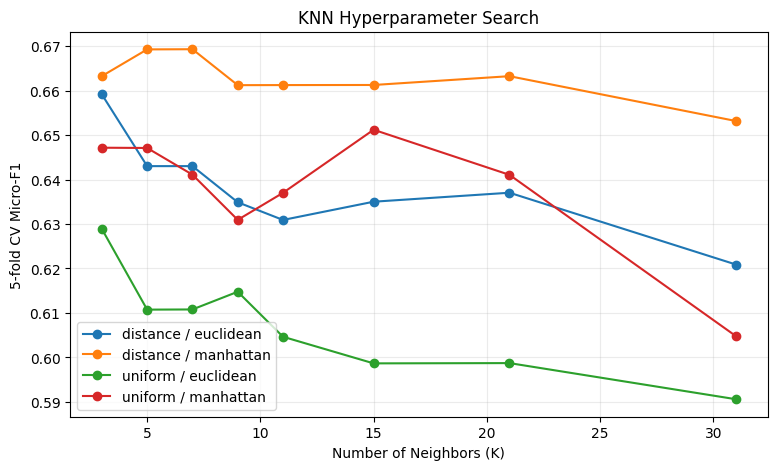

In [29]:
# Plot CV performance against K for the best weighting/metric combinations
plot_df = cv_results.copy()
plot_df["K"] = plot_df["param_knn__n_neighbors"].astype(int)

plt.figure(figsize=(9, 5))

for (weights, metric), group in plot_df.groupby(
    ["param_knn__weights", "param_knn__metric"]
):
    group = group.sort_values("K")
    plt.plot(
        group["K"],
        group["mean_test_score"],
        marker="o",
        label=f"{weights} / {metric}"
    )

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("5-fold CV Micro-F1")
plt.title("KNN Hyperparameter Search")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Evaluate the final KNN model on the held-out test set

The test set is used only now, after the best KNN configuration has been selected.

This follows the reference methodology: select the model using the training data and cross-validation, then evaluate the final model once on the held-out test set.


In [30]:
best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average="micro")
test_f1 = f1_score(y_test, y_test_pred, average="micro")

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Micro-F1 : {train_f1:.4f}")
print(f"CV Micro-F1       : {grid_search.best_score_:.4f}")
print(f"Test Micro-F1     : {test_f1:.4f}")
print()
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy     : {test_accuracy:.4f}")


Training Micro-F1 : 1.0000
CV Micro-F1       : 0.6693
Test Micro-F1     : 0.6532

Training Accuracy : 1.0000
Test Accuracy     : 0.6532


## 9. Classification report

Micro-F1 is the main metric for comparison, but the classification report helps us understand performance for individual regimes.


In [31]:
print(classification_report(y_test, y_test_pred, digits=4))


              precision    recall  f1-score   support

           1     0.8529    0.6591    0.7436        44
           2     0.6585    0.7297    0.6923        37
           3     0.5161    0.6400    0.5714        25
           5     0.5000    0.5000    0.5000        18

    accuracy                         0.6532       124
   macro avg     0.6319    0.6322    0.6268       124
weighted avg     0.6758    0.6532    0.6582       124



## 10. Confusion matrix

The confusion matrix is useful for the presentation/demo because it shows which reef regimes KNN confuses most often.


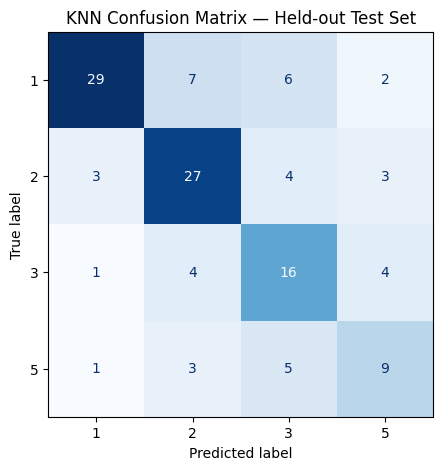

In [32]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("KNN Confusion Matrix — Held-out Test Set")
plt.show()


## 11. Compare KNN with the reference project

The reference paper reports these validation micro-F1 scores:

| Reference model | Validation Micro-F1 |
|---|---:|
| Logistic Regression — Baseline | 0.60 |
| Logistic Regression — Mean NA | 0.66 |
| Logistic Regression — Imputed NA | 0.64 |
| Logistic Regression — Regularized | 0.62 |
| Logistic Regression — Feature Engineered | 0.62 |
| SVM — Radial Kernel | 0.65 |
| SVM — Polynomial Kernel | 0.61 |
| Random Forest | 0.70 |
| Gradient Boosted Tree | 0.69 |

The original project also reports **0.70 test micro-F1 for its final Random Forest**.

The next cell creates a comparison table and inserts the KNN result from this notebook.


In [33]:
import pandas as pd

# Load the replicated reference models from Part 1
try:
    reference_results = pd.read_csv("replicated_reference_models.csv")
except FileNotFoundError:
    print("Error: Run Part 1 replication first to generate the CSV.")
    reference_results = pd.DataFrame(columns=["Model", "CV_Micro_F1", "Test_Micro_F1"])

# Create a DataFrame for your new KNN model
knn_results = pd.DataFrame({
    "Model": ["KNN — Our Extension"],
    "CV_Micro_F1": [grid_search.best_score_],
    "Test_Micro_F1": [test_f1]
})

# Combine them into a single comparison table
final_comparison = pd.concat([reference_results, knn_results], ignore_index=True)
display(final_comparison)

,Model,CV_Micro_F1,Test_Micro_F1
0,Logistic Regression (Replicated),0.618929,0.580645
1,Random Forest (Replicated),0.675414,0.725806
2,KNN — Our Extension,0.669293,0.653226


In [34]:
# Simple interpretation
reference_best_cv = 0.70
difference_from_best_reference = grid_search.best_score_ - reference_best_cv

print(f"KNN CV Micro-F1: {grid_search.best_score_:.4f}")
print(f"Best reference CV Micro-F1: {reference_best_cv:.4f}")
print(f"Difference: {difference_from_best_reference:+.4f}")

if difference_from_best_reference > 0.01:
    interpretation = "KNN performs better than the best reported reference validation score."
elif difference_from_best_reference < -0.01:
    interpretation = "KNN performs worse than the best reported reference validation score."
else:
    interpretation = "KNN performs similarly to the best reported reference validation score."

print("\nInterpretation:", interpretation)


KNN CV Micro-F1: 0.6693
Best reference CV Micro-F1: 0.7000
Difference: -0.0307

Interpretation: KNN performs worse than the best reported reference validation score.


## 12. Optional: save the numerical results

These files can be uploaded to the GitHub repository as project outputs.


In [35]:
# Save outputs
cv_results.to_csv("knn_cv_results.csv", index=False)
final_comparison.to_csv("model_comparison.csv", index=False)
pd.DataFrame(cm, index=labels, columns=labels).to_csv("knn_confusion_matrix.csv")
print("Saved outputs successfully.")

print("Saved:")
print("- knn_cv_results.csv")
print("- model_comparison.csv")
print("- knn_confusion_matrix.csv")


Saved outputs successfully.
Saved:
- knn_cv_results.csv
- model_comparison.csv
- knn_confusion_matrix.csv


## 13. Part 2 conclusion — fill in the actual numbers

After running the notebook, replace the bracketed values below with the printed results.

> **Conclusion:** K-Nearest Neighbors was selected as our additional model because it provides a simple, distance-based alternative to the Logistic Regression and tree-based models used in the original paper. We maintained a strict apples-to-apples comparison by using the exact same 80/20 data split, 25 environmental predictors, 5-fold cross-validation, and the micro-averaged F1 metric. After testing various configurations, our best KNN model used 7 neighbors, distance weighting, and manhattan distance. It achieved a cross-validation micro-F1 of 0.6693 and a held-out test micro-F1 of 0.6532. Compared with the reference project's best Random Forest test score of 0.70, our KNN performed worse. This result makes sense ecologically: while KNN successfully handles the scaled data and beats simpler baselines, tree-based models are naturally better at mapping out the messy, non-linear rules of nature than a pure spatial-distance algorithm.